In [1]:
# Cell 1 — imports and DB connection
import sys
sys.path.append('../backend')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import os
import xgboost as xgb
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv('../.env')

DB_USER = os.getenv("DB_USER", "postgres")
DB_PASS = os.getenv("DB_PASS", "")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "cementops")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected!")

Connected!


In [2]:
# Cell 2 — load and pivot data
df_raw = pd.read_sql("""
    SELECT machine_id, metric_name, value, is_anomaly, timestamp
    FROM sensor_readings
    ORDER BY timestamp ASC
""", engine)

print(f"Total rows: {len(df_raw)}")
print(f"Metrics: {df_raw['metric_name'].unique()}")

# Pivot: one row per timestamp, one column per metric
df = df_raw.pivot_table(
    index='timestamp',
    columns='metric_name',
    values='value',
    aggfunc='mean'
).reset_index()

df.columns.name = None
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"\nPivoted shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Total rows: 5808
Metrics: <ArrowStringArray>
[  'kiln_temperature',     'kiln_feed_rate',           'kiln_rpm',
 'mill_motor_current',     'mill_vibration',   'cooler_exit_temp']
Length: 6, dtype: str

Pivoted shape: (5803, 7)
Columns: ['timestamp', 'cooler_exit_temp', 'kiln_feed_rate', 'kiln_rpm', 'kiln_temperature', 'mill_motor_current', 'mill_vibration']


,timestamp,cooler_exit_temp,kiln_feed_rate,kiln_rpm,kiln_temperature,mill_motor_current,mill_vibration
0,2026-06-01 11:15:47.238272+00:00,NaN,NaN,NaN,1363.419,NaN,NaN
1,2026-06-01 11:15:47.238459+00:00,NaN,151.332,NaN,NaN,NaN,NaN
2,2026-06-01 11:15:47.238506+00:00,NaN,NaN,3.44,NaN,NaN,NaN
3,2026-06-01 11:15:47.238544+00:00,NaN,NaN,NaN,NaN,203.729,NaN
4,2026-06-01 11:15:47.238579+00:00,NaN,NaN,NaN,NaN,NaN,2.87


In [3]:
# Cell 3 — fix pivot using time-based grouping
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], utc=True)

# Round timestamps to 5-second buckets so all sensors align
df_raw['ts_bucket'] = df_raw['timestamp'].dt.floor('5s')

df = df_raw.pivot_table(
    index='ts_bucket',
    columns='metric_name',
    values='value',
    aggfunc='mean'
).reset_index()

df.columns.name = None
df = df.sort_values('ts_bucket').reset_index(drop=True)

# Forward fill small gaps
df = df.ffill().bfill()

# Drop any remaining NaN rows
df = df.dropna().reset_index(drop=True)

print(f"Clean pivoted shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nSample data:")
df.head(3)

Clean pivoted shape: (774, 7)
Columns: ['ts_bucket', 'cooler_exit_temp', 'kiln_feed_rate', 'kiln_rpm', 'kiln_temperature', 'mill_motor_current', 'mill_vibration']

Sample data:


,ts_bucket,cooler_exit_temp,kiln_feed_rate,kiln_rpm,kiln_temperature,mill_motor_current,mill_vibration
0,2026-06-01 11:15:45+00:00,87.638,151.332,3.440,1363.419,203.729,2.870
1,2026-06-01 11:15:50+00:00,86.262,155.127,3.375,1357.950,197.472,3.569
2,2026-06-01 11:15:55+00:00,87.525,159.103,3.443,1369.058,188.162,3.059


In [4]:
# Cell 4 — feature engineering
df = df.sort_values('ts_bucket').reset_index(drop=True)

sensors = ['cooler_exit_temp', 'kiln_feed_rate', 'kiln_rpm',
           'kiln_temperature', 'mill_motor_current', 'mill_vibration']

# Rolling statistics (20-sample window)
for col in sensors:
    df[f'{col}_mean20'] = df[col].rolling(20, min_periods=1).mean()
    df[f'{col}_std20']  = df[col].rolling(20, min_periods=1).std().fillna(0)

# Lag features for kiln_temperature
for lag in [1, 5, 10]:
    df[f'kiln_temp_lag{lag}'] = df['kiln_temperature'].shift(lag)

# Trend: slope of kiln_temperature over last 10 readings
def rolling_slope(series, window=10):
    slopes = []
    for i in range(len(series)):
        if i < window:
            slopes.append(0)
        else:
            y = series.iloc[i-window:i].values
            x = np.arange(window)
            slope = np.polyfit(x, y, 1)[0]
            slopes.append(slope)
    return slopes

df['kiln_temp_slope'] = rolling_slope(df['kiln_temperature'])

# Time features
df['hour'] = pd.to_datetime(df['ts_bucket']).dt.hour
df['is_day_shift'] = ((df['hour'] >= 6) & (df['hour'] < 18)).astype(int)

# Target: kiln_temperature 10 steps ahead (50 seconds)
df['target'] = df['kiln_temperature'].shift(-10)

# Drop NaN rows created by lags and target shift
df = df.dropna().reset_index(drop=True)

feature_cols = [c for c in df.columns
                if c not in ['ts_bucket', 'target']]

print(f"Features: {len(feature_cols)}")
print(f"Rows after feature engineering: {len(df)}")
print(f"\nFeature list:")
for f in feature_cols:
    print(f"  {f}")

Features: 24
Rows after feature engineering: 754

Feature list:
  cooler_exit_temp
  kiln_feed_rate
  kiln_rpm
  kiln_temperature
  mill_motor_current
  mill_vibration
  cooler_exit_temp_mean20
  cooler_exit_temp_std20
  kiln_feed_rate_mean20
  kiln_feed_rate_std20
  kiln_rpm_mean20
  kiln_rpm_std20
  kiln_temperature_mean20
  kiln_temperature_std20
  mill_motor_current_mean20
  mill_motor_current_std20
  mill_vibration_mean20
  mill_vibration_std20
  kiln_temp_lag1
  kiln_temp_lag5
  kiln_temp_lag10
  kiln_temp_slope
  hour
  is_day_shift


In [5]:
# Cell 5 — train XGBoost model
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

X = df[feature_cols].values
y = df['target'].values

# Time-based split — never random for time series!
split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train size: {len(X_train)} rows")
print(f"Test size:  {len(X_test)} rows")

# Train model
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\nModel Results:")
print(f"RMSE: {rmse:.3f} °C")
print(f"MAPE: {mape:.2f}%")
print(f"\nTarget: RMSE < 10, MAPE < 5%")

Train size: 603 rows
Test size:  151 rows

Model Results:
RMSE: 13.090 °C
MAPE: 0.74%

Target: RMSE < 10, MAPE < 5%


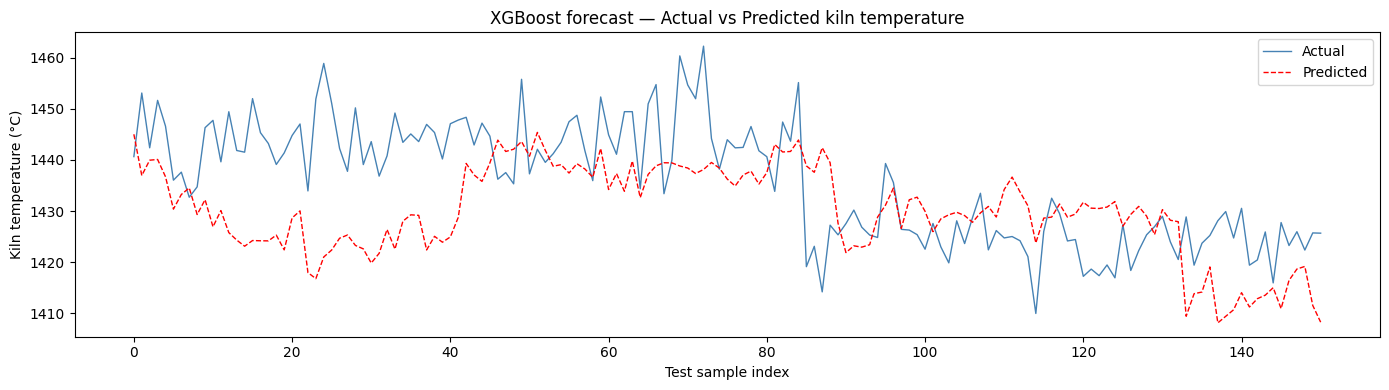

Plot saved!


In [6]:
# Cell 6 — plot actual vs predicted
plt.figure(figsize=(14, 4))
plt.plot(y_test, color='steelblue', linewidth=1, label='Actual')
plt.plot(y_pred, color='red', linewidth=1, linestyle='--', label='Predicted')
plt.title('XGBoost forecast — Actual vs Predicted kiln temperature')
plt.xlabel('Test sample index')
plt.ylabel('Kiln temperature (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('../backend/models/forecast_plot.png', dpi=150)
plt.show()
print("Plot saved!")

In [7]:
# Cell 7 — save model and metadata
import json, joblib, os

os.makedirs('../backend/models', exist_ok=True)

# Save model
joblib.dump(model, '../backend/models/forecast_model.pkl')

# Save feature column names
joblib.dump(feature_cols, '../backend/models/forecast_features.pkl')

# Save model metadata
rmse_val = float(np.sqrt(mean_squared_error(y_test, y_pred)))
metadata = {
    "rmse": round(rmse_val, 3),
    "mape": round(float(mape), 3),
    "n_features": len(feature_cols),
    "train_size": len(X_train),
    "test_size": len(X_test),
    "target": "kiln_temperature_10steps_ahead",
    "confidence_margin": round(rmse_val * 1.5, 3)
}
with open('../backend/models/forecast_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model saved!")
print(f"Files saved:")
print(f"  backend/models/forecast_model.pkl")
print(f"  backend/models/forecast_features.pkl")
print(f"  backend/models/forecast_metadata.json")
print(f"  backend/models/forecast_plot.png")
print(f"\nMetadata: {metadata}")

Model saved!
Files saved:
  backend/models/forecast_model.pkl
  backend/models/forecast_features.pkl
  backend/models/forecast_metadata.json
  backend/models/forecast_plot.png

Metadata: {'rmse': 13.09, 'mape': 0.741, 'n_features': 24, 'train_size': 603, 'test_size': 151, 'target': 'kiln_temperature_10steps_ahead', 'confidence_margin': 19.635}


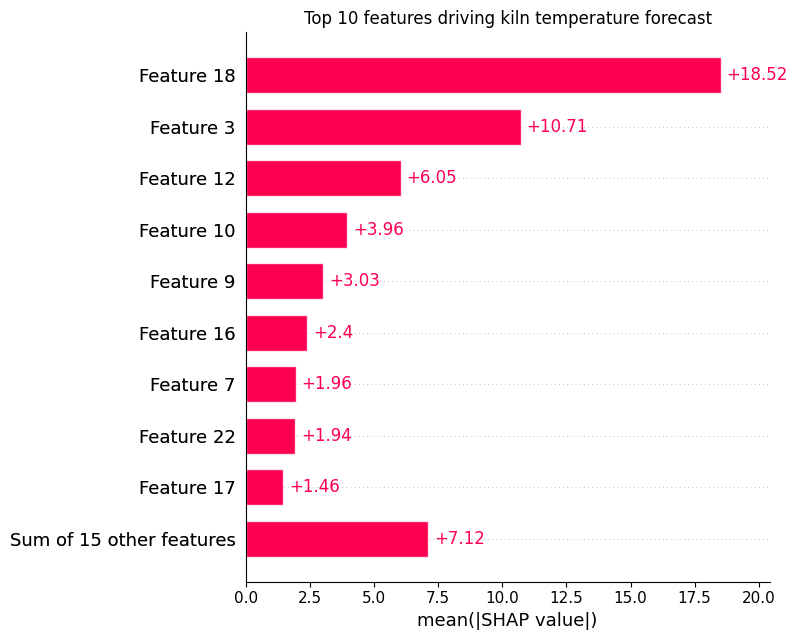

SHAP bar chart saved!


In [8]:
# Cell 8 — SHAP explainability
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Summary bar chart — top 10 most important features
plt.figure()
shap.plots.bar(shap_values, max_display=10, show=False)
plt.title('Top 10 features driving kiln temperature forecast')
plt.tight_layout()
plt.savefig('../backend/models/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP bar chart saved!")

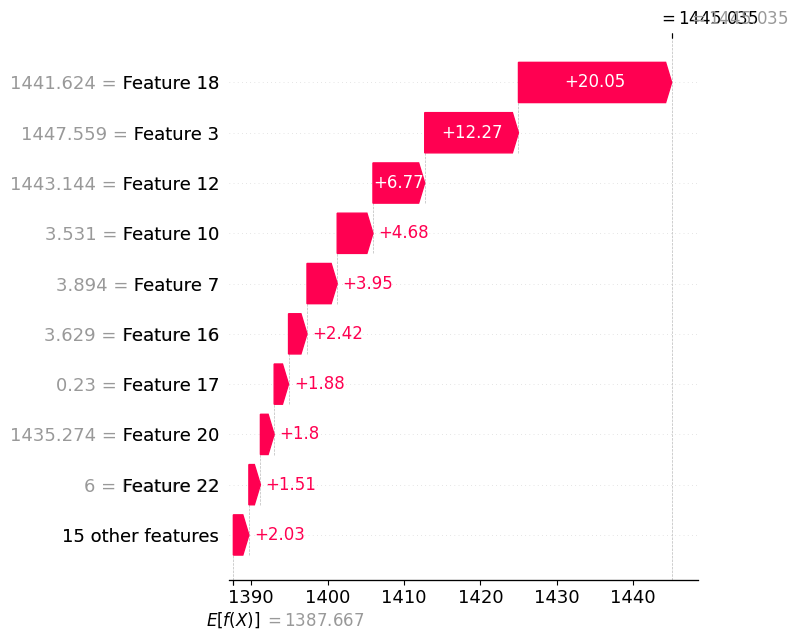

Waterfall chart saved!


In [9]:
# Cell 9 — SHAP waterfall for single prediction
plt.figure()
shap.plots.waterfall(shap_values[0], show=False)
plt.tight_layout()
plt.savefig('../backend/models/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall chart saved!")

In [10]:
# Cell 10 — save SHAP feature importances as JSON
import json
import numpy as np

# Get mean absolute SHAP values per feature
mean_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = dict(zip(feature_cols, mean_shap.tolist()))

# Sort by importance
shap_importance = dict(
    sorted(shap_importance.items(), key=lambda x: x[1], reverse=True)
)

# Save top 10
top10 = dict(list(shap_importance.items())[:10])
with open('../backend/models/shap_importance.json', 'w') as f:
    json.dump(top10, f, indent=2)

print("Top 10 SHAP features:")
for feat, val in top10.items():
    bar = "█" * int(val / max(top10.values()) * 20)
    print(f"  {feat:30} {bar} {val:.4f}")

print("\nshap_importance.json saved!")

Top 10 SHAP features:
  kiln_temp_lag1                 ████████████████████ 18.5235
  kiln_temperature               ███████████ 10.7134
  kiln_temperature_mean20        ██████ 6.0479
  kiln_rpm_mean20                ████ 3.9644
  kiln_feed_rate_std20           ███ 3.0261
  mill_vibration_mean20          ██ 2.3995
  cooler_exit_temp_std20         ██ 1.9618
  hour                           ██ 1.9409
  mill_vibration_std20           █ 1.4639
  kiln_rpm_std20                 █ 1.3765

shap_importance.json saved!
